In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from keras.datasets import mnist

/Users/celinalinnerblom/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
(Xtr, Ltr), (X_test, L_test)=mnist.load_data()

Xtr=Xtr / 255.0
X_test=X_test / 255.0

In [4]:
Xtr.shape

(60000, 28, 28)

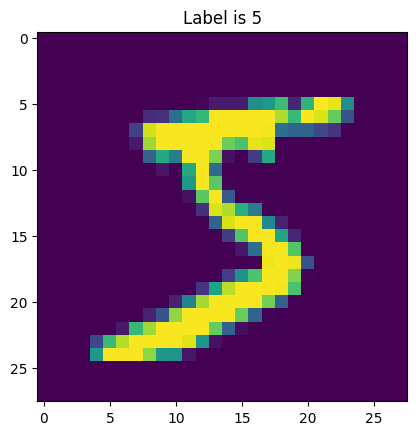

In [5]:
Image=Xtr[0,:,:]
Label=Ltr[0]


plt.title('Label is {Label}'.format(Label=Label))
plt.imshow(Image)

plt.show()
plt.close()


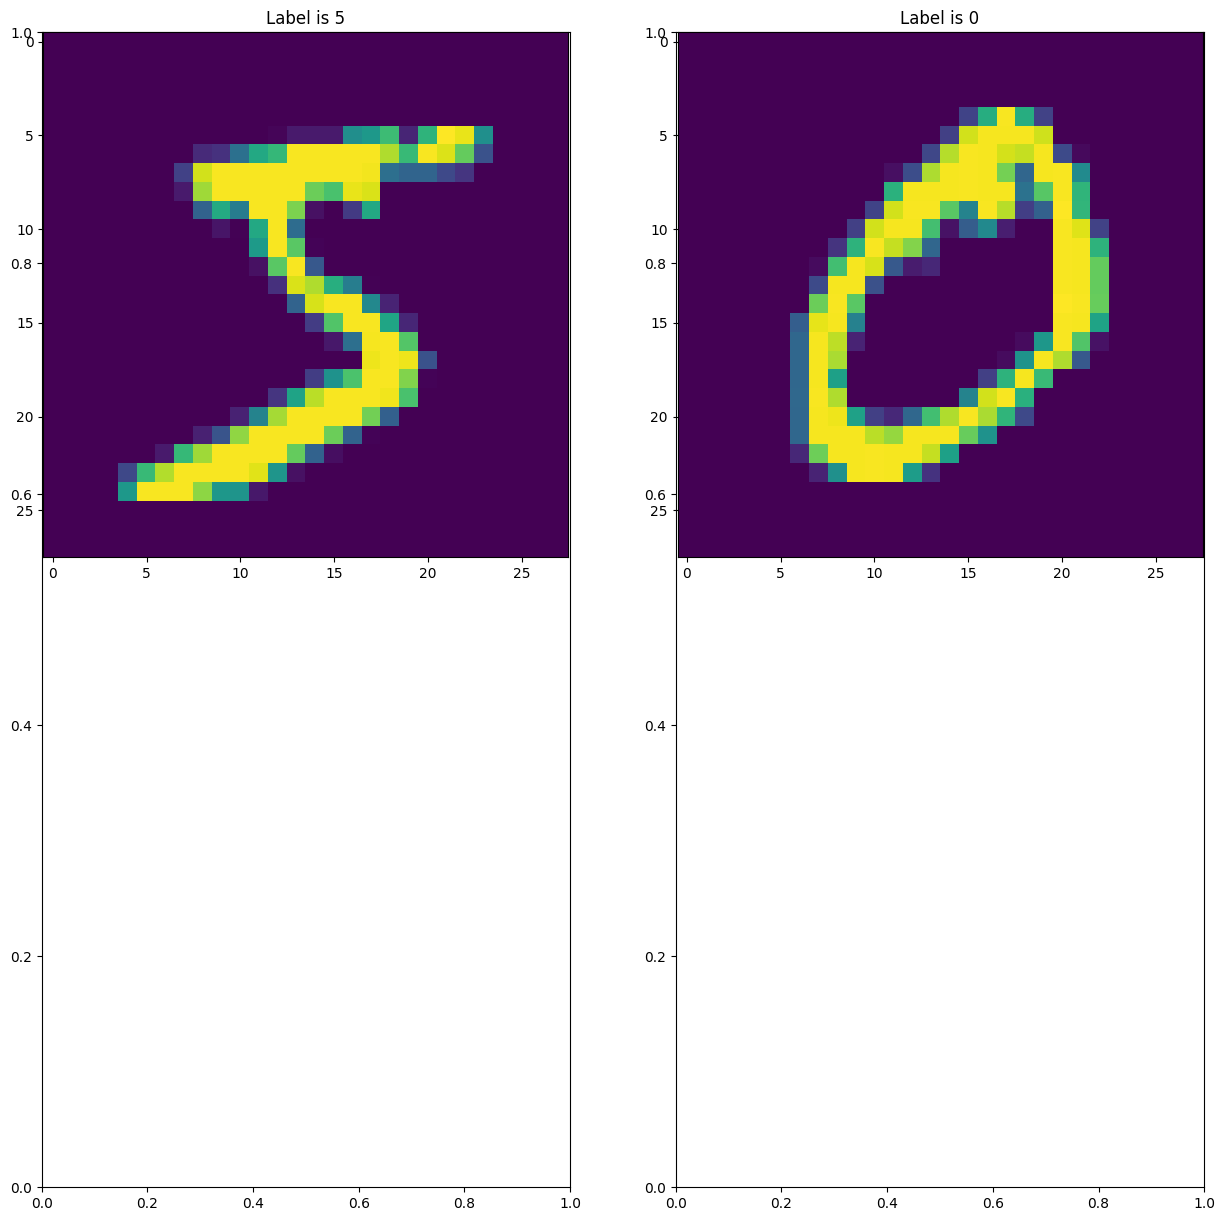

In [6]:
fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(15,15))
ax0=plt.subplot(2,2,1)
ax1=plt.subplot(2,2,2)

Image=Xtr[0,:,:]
Label=Ltr[0]
Image1=Xtr[1,:,:]
Label1=Ltr[1]


ax0.set_title('Label is {Label}'.format(Label=Label))
ax0.imshow(Image)
ax1.set_title('Label is {Label}'.format(Label=Label1))
ax1.imshow(Image1)


plt.show()
plt.close()


In [7]:
28*28

784

In [8]:
#Traing phase
num_sample=500
Tr_set=Xtr[:num_sample,:,:]
Ltr_set=Ltr[:num_sample]

Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2])

#Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2]).astype()
Tr_set.shape

(500, 784)

In [ ]:
#1-NN classifier
def predict(X):
    num_test=X.shape[0]
    Lpred=np.zeros(num_test, dtype=Ltr.dtype) #creates an empty array to store predicted labels
    
    for i in range(num_test):
        distances = np.sqrt(np.sum((Tr_set - X[i,:])**2, axis=1)) #computes Euclidean distances
        min_index= np.argmin(distances) #finds the index of image with the smallest distance 

        Lpred[i]=Ltr_set[min_index] 
    return Lpred

#K-NN classifier 
def predict_kNN(X, k):
    num_test = X.shape[0]
    Lpred = np.zeros(num_test, dtype=Ltr_set.dtype)

    for i in range(num_test):
        distances = np.sqrt(np.sum((Tr_set - X[i,:])**2, axis=1))  #computes distances

        k_indices = np.argsort(distances)[:k] #sorts the distances and selects the indices of the k nearest neighbours
        k_labels = Ltr_set[k_indices] #get the labels of the k nearest neighbours

        Lpred[i] = np.bincount(k_labels).argmax() #uses majority voting to determine the predicted label
    return Lpred


In [ ]:
Test_images=X_test.reshape(X_test.shape[0],X_test.shape[1]* X_test.shape[2])

#Labels_predicted=predict(Test_images)

Labels_predicted=predict_kNN(Test_images, k=6)

print("Accuracy:", np.mean(Labels_predicted==L_test))


Accuracy: 0.8061
